# Similarity Score Histogram — Dynamic k Thresholding

Embeds a text query with SigLIP and computes cosine similarity against **every**
frame in the indexed collection.  The resulting distribution is plotted as a
histogram so we can see whether there is a natural gap that separates relevant
frames from the background — the basis for a histogram-threshold-based dynamic k.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import k3d

# ── ensure project root is on sys.path and is the working directory ──────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = Path("__file__").resolve().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Using device : {device}")

Project root : /usr/prakt/s0036/AppliedFoundationModels
Using device : cuda


## Dataset & query config

In [2]:
SCENE_DIR  = "/storage/group/dataset_mirrors/scannet/scans/scene0011_00"
COLLECTION = "scannet_scene0011_00"

QUERY = "Chair"   # ← change to anything

## Load SigLIP + DB

In [3]:
import yaml
from src.models import SigLIPModel
from src.utils.db import connect as db_connect

cfg    = yaml.safe_load(Path("config.yaml").read_text())
db     = db_connect(cfg["indexing"]["db_path"])
siglip = SigLIPModel.from_config("config.yaml")

table = db.open_table(COLLECTION)
n_frames = table.count_rows()
print(f"Collection : {COLLECTION}  ({n_frames:,} frames)")

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Collection : scannet_scene0011_00  (2,374 frames)


## Embed query and score all frames

We search with LanceDB's cosine `distance_type`, so `_distance` is the cosine
*distance* (`1 - cosine similarity`).  Convert it back to similarity
(`sim = 1 - _distance`, higher = closer) before any thresholding.  We call
`.search(...).limit(n_frames)` to retrieve every row ordered by similarity.

In [4]:
query_emb = siglip.embed_text(QUERY)   # 1-D L2-normalised ndarray

rows = (
    table.search(query_emb.tolist())
    .distance_type("cosine")
    .limit(n_frames)
    .to_list()
)

# With the cosine distance_type, _distance is the cosine *distance*
# (1 - cosine similarity), so higher = farther away.  Convert to cosine
# similarity (higher = closer) before any thresholding — otherwise every
# ">= threshold" selection below would keep the most DISSIMILAR frames.
similarities = np.array(
    [1.0 - float(r["_distance"]) for r in rows],
    dtype=np.float32,
)
paths = [r["path"] for r in rows]

print(f"Query       : '{QUERY}'")
print(f"Scores      : min={similarities.min():.4f}  "
      f"max={similarities.max():.4f}  "
      f"mean={similarities.mean():.4f}  "
      f"std={similarities.std():.4f}")

Query       : 'Chair'
Scores      : min=0.0386  max=0.0836  mean=0.0588  std=0.0068


## Histogram of similarity scores

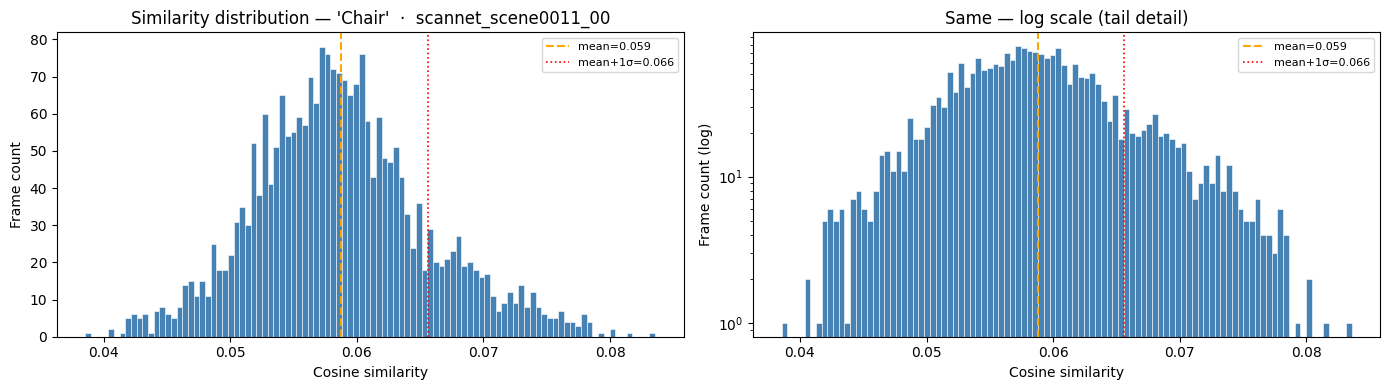

In [5]:
N_BINS = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── left: linear y-scale ─────────────────────────────────────────────────────
ax = axes[0]
counts, bin_edges, patches = ax.hist(similarities, bins=N_BINS, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frame count")
ax.set_title(f"Similarity distribution — '{QUERY}'  ·  {COLLECTION}")
ax.axvline(similarities.mean(), color="orange", linewidth=1.5, linestyle="--", label=f"mean={similarities.mean():.3f}")
ax.axvline(similarities.mean() + similarities.std(), color="red", linewidth=1.2, linestyle=":", label=f"mean+1σ={similarities.mean()+similarities.std():.3f}")
ax.legend(fontsize=8)

# ── right: log y-scale to reveal the tail structure ──────────────────────────
ax2 = axes[1]
ax2.hist(similarities, bins=N_BINS, color="steelblue", edgecolor="white", linewidth=0.4, log=True)
ax2.set_xlabel("Cosine similarity")
ax2.set_ylabel("Frame count (log)")
ax2.set_title("Same — log scale (tail detail)")
ax2.axvline(similarities.mean(), color="orange", linewidth=1.5, linestyle="--", label=f"mean={similarities.mean():.3f}")
ax2.axvline(similarities.mean() + similarities.std(), color="red", linewidth=1.2, linestyle=":", label=f"mean+1σ={similarities.mean()+similarities.std():.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Otsu thresholding

Otsu's method assumes the scores form **two** clusters (relevant vs. background)
and picks the split `t*` that maximises the between-class variance σ²_B(t).

Besides the threshold we compute Otsu's *effectiveness metric*
**η = σ²_B(t*) / σ²_total ∈ [0, 1]** — how much of the total variance the
two-cluster split explains.  Careful with its calibration: η is **not** near 0
for unimodal data — a pure Gaussian already yields η ≈ 2/π ≈ **0.64** and a
uniform distribution **0.75**.  Only values above the uniform baseline indicate
a genuine relevant cluster; below it the scores are one background blob
(object likely not in the scene).  `dynamic_k_retrieve` gates on
η ≥ 0.75 and falls back to plain top-`min_k` otherwise — the sanity check
below validates this cutoff on present vs. absent objects.

In [6]:
def _otsu_curve(similarities) -> tuple[np.ndarray, np.ndarray, float]:
    """Between-class variance σ²_B(t) over 256 candidate thresholds.

    Returns (bin_centers, sigma_b_sq, total_variance).
    """
    sims = np.asarray(similarities, dtype=np.float32)

    # Discretize into bins (like pixel intensity levels 0-255)
    hist, bin_edges = np.histogram(sims, bins=256)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    hist = hist.astype(float)
    total = hist.sum()

    # Cumulative sums and means
    weight_bg = np.cumsum(hist) / total           # ω₀(t)
    weight_fg = 1.0 - weight_bg                   # ω₁(t)

    cum_mean = np.cumsum(hist * bin_centers) / total
    global_mean = cum_mean[-1]

    # Guarded divisions: np.where still evaluates the divide everywhere,
    # so use np.divide(..., where=...) to avoid 0/0 warnings at the ends.
    mean_bg = np.divide(cum_mean, weight_bg,
                        out=np.zeros_like(weight_bg), where=weight_bg > 0)
    mean_fg = np.divide(global_mean - cum_mean, weight_fg,
                        out=np.zeros_like(weight_fg), where=weight_fg > 0)

    # Between-class variance σ²_B(t) — maximise this
    sigma_b_sq = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
    return bin_centers, sigma_b_sq, float(sims.var())


def otsu_threshold(similarities) -> float:
    """
    Find the optimal similarity threshold via Otsu's method.
    Adapted from image binarization — treats similarity scores
    as a 1D 'intensity histogram'.
    """
    bin_centers, sigma_b_sq, _ = _otsu_curve(similarities)
    return float(bin_centers[np.argmax(sigma_b_sq)])


def otsu_separability(similarities) -> float:
    """
    Otsu's effectiveness metric  η = σ²_B(t*) / σ²_total  ∈ [0, 1].

    Calibration — η is NOT near 0 for unimodal data:
      * pure Gaussian        η ≈ 2/π ≈ 0.64   (best split of one blob)
      * uniform              η = 0.75
      * two separated modes  η → 1
    Empirically on scannet_scene0011_00: absent objects ('Auto',
    'an elephant') land at 0.63–0.71, present furniture at ≈ 0.79+.
    The uniform baseline 0.75 separates the two groups cleanly, so we
    use it as the default gate below.
    """
    _, sigma_b_sq, var_total = _otsu_curve(similarities)
    if var_total == 0.0:
        return 0.0
    return float(sigma_b_sq.max() / var_total)


def dynamic_k_retrieve(query_vec, doc_vecs, doc_ids,
                       min_k: int = 1, max_k: int = 20,
                       min_separability: float = 0.75):
    """
    Retrieve a dynamic number of docs using Otsu thresholding.

    Safety nets:
      * min_k / max_k clamp the result size in both directions.
      * If the score distribution is effectively unimodal
        (otsu_separability < min_separability, i.e. no better than
        splitting a uniform blob) the threshold sits in noise —
        fall back to plain top-min_k.

    Returns (results, k, threshold, separability).
    """
    # Cosine similarities (assumes unit-normalised vectors)
    sims = (doc_vecs @ query_vec).tolist()

    threshold = otsu_threshold(sims)
    separability = otsu_separability(sims)

    if separability < min_separability:
        # No distinct relevant cluster — likely "object not in scene".
        results = sorted(zip(sims, doc_ids), reverse=True)[:min_k]
        return results, len(results), threshold, separability

    # Collect docs above threshold, sorted by score
    results = sorted(
        [(s, did) for s, did in zip(sims, doc_ids) if s >= threshold],
        reverse=True
    )

    # Safety clamp
    results = results[:max_k]
    if len(results) < min_k:
        # Fall back to top-k if Otsu finds nothing
        results = sorted(zip(sims, doc_ids), reverse=True)[:min_k]

    k = len(results)
    return results, k, threshold, separability

## Apply to the full collection

In [7]:
threshold = otsu_threshold(similarities)
separability = otsu_separability(similarities)
k_dynamic = int((similarities >= threshold).sum())

print(f"Query        : '{QUERY}'")
print(f"Threshold    : {threshold:.4f}")
print(f"Separability : η = {separability:.3f}   (gate 0.75 — "
      f"{'unimodal, object likely absent' if separability < 0.75 else 'distinct relevant cluster'})")
print(f"Dynamic k    : {k_dynamic}  /  {n_frames:,} total frames")

Query        : 'Chair'
Threshold    : 0.0597
Separability : η = 0.610   (gate 0.75 — unimodal, object likely absent)
Dynamic k    : 971  /  2,374 total frames


## Sanity check: present vs. absent objects

Runs `dynamic_k_retrieve` end-to-end for several queries, re-using the frame
embeddings already fetched from LanceDB.  Queries for objects **absent** from
the scene should sit near the ≈ 0.64 Gaussian η-baseline and trigger the
top-`min_k` fallback; objects actually **in** the scene should separate more
cleanly (higher η) and receive a data-driven k.

In [8]:
# Reuse the stored frame embeddings — each query is then one matrix product.
doc_vecs = np.array([r["vector"] for r in rows], dtype=np.float32)   # (N, D)
doc_ids  = [r["id"] for r in rows]

MIN_SEP = 0.75   # uniform-distribution baseline; see otsu_separability
TEST_QUERIES = [
    "Auto",             # car — not in an indoor scan
    "an elephant",      # definitely absent
    "chair",            # common ScanNet furniture
    "sofa",
    "table",
    "a kitchen counter",
]

print(f"{'query':<22} {'η':>7} {'threshold':>10} {'k':>6}   selection")
print("-" * 62)
for q in TEST_QUERIES:
    q_vec = siglip.embed_text(q)
    _, k, thr, eta = dynamic_k_retrieve(
        q_vec, doc_vecs, doc_ids,
        min_k=3, max_k=n_frames, min_separability=MIN_SEP,
    )
    mode = "top-min_k fallback" if eta < MIN_SEP else "otsu threshold"
    print(f"{q:<22} {eta:>7.3f} {thr:>10.4f} {k:>6}   {mode}")

query                        η  threshold      k   selection
--------------------------------------------------------------
Auto                     0.631     0.0614      3   top-min_k fallback
an elephant              0.704     0.0209      3   top-min_k fallback
chair                    0.798     0.0790   1405   otsu threshold
sofa                     0.794     0.0608   1476   otsu threshold
table                    0.794     0.0889   1391   otsu threshold
a kitchen counter        0.706     0.0889      3   top-min_k fallback


## More selective thresholds

Plain Otsu sees the whole distribution and often splits near the centre of mass.
Three progressively stricter strategies:

| strategy | idea |
|---|---|
| **tail-Otsu** | run Otsu only on scores ≥ mean — ignore the background mass entirely |
| **recursive Otsu** | apply Otsu → take the foreground → apply Otsu again on that subset |
| **Otsu + σ floor** | `max(otsu_threshold, mean + k·σ)` — hard lower bound |

In [9]:
# ── strategy 1: tail-Otsu ─────────────────────────────────────────────────────
# Restrict the input to scores above the mean so Otsu finds the split
# inside the high-similarity region rather than across the full range.
tail = similarities[similarities >= similarities.mean()]
thresh_tail = otsu_threshold(tail.tolist())
k_tail = int((similarities >= thresh_tail).sum())

# ── strategy 2: recursive Otsu ────────────────────────────────────────────────
# Apply Otsu once to get a rough foreground, then apply it again within
# that foreground to find the tighter split.
thresh_plain = otsu_threshold(similarities.tolist())
fg = similarities[similarities >= thresh_plain]
thresh_recursive = otsu_threshold(fg.tolist()) if len(fg) > 1 else thresh_plain
k_recursive = int((similarities >= thresh_recursive).sum())

# ── strategy 3: Otsu + σ floor ────────────────────────────────────────────────
SIGMA_FLOOR = 1.0   # ← tune: higher = stricter
thresh_floor = max(thresh_plain, float(similarities.mean() + SIGMA_FLOOR * similarities.std()))
k_floor = int((similarities >= thresh_floor).sum())

print(f"{'strategy':<20} {'threshold':>10}  {'k':>6}")
print("-" * 42)
print(f"{'plain Otsu':<20} {thresh_plain:>10.4f}  {int((similarities >= thresh_plain).sum()):>6}")
print(f"{'tail-Otsu':<20} {thresh_tail:>10.4f}  {k_tail:>6}")
print(f"{'recursive Otsu':<20} {thresh_recursive:>10.4f}  {k_recursive:>6}")
print(f"{'Otsu + {:.0f}σ floor'.format(SIGMA_FLOOR):<20} {thresh_floor:>10.4f}  {k_floor:>6}")

strategy              threshold       k
------------------------------------------
plain Otsu               0.0597     971
tail-Otsu                0.0663     322
recursive Otsu           0.0667     312
Otsu + 1σ floor          0.0656     364


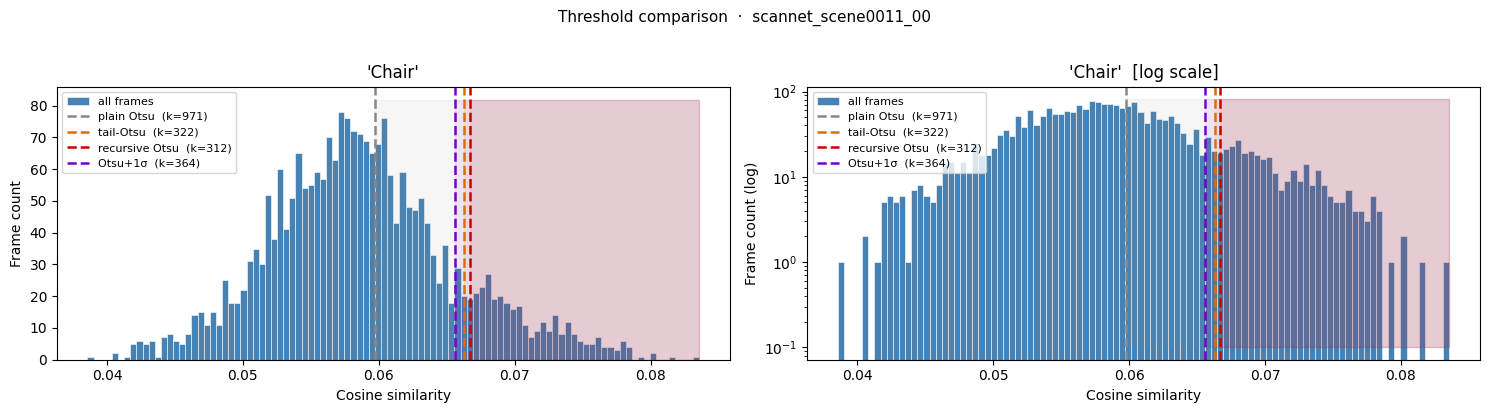

In [10]:
thresholds = [
    (thresh_plain,     "#888888", f"plain Otsu  (k={int((similarities >= thresh_plain).sum())})"),
    (thresh_tail,      "#e06c00", f"tail-Otsu  (k={k_tail})"),
    (thresh_recursive, "#cc0000", f"recursive Otsu  (k={k_recursive})"),
    (thresh_floor,     "#7000cc", f"Otsu+{SIGMA_FLOOR:.0f}σ  (k={k_floor})"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, log_scale in zip(axes, [False, True]):
    counts, _, _ = ax.hist(
        similarities, bins=N_BINS,
        color="steelblue", edgecolor="white", linewidth=0.4,
        log=log_scale, label="all frames",
    )
    y_top = counts.max() * 1.05
    y_bot = 1e-1 if log_scale else 0
    for thresh, color, label in thresholds:
        ax.axvline(thresh, color=color, linewidth=1.8, linestyle="--", label=label)
        ax.fill_betweenx(
            [y_bot, y_top], thresh, float(similarities.max()),
            color=color, alpha=0.07,
        )
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Frame count" + (" (log)" if log_scale else ""))
    ax.set_title(f"'{QUERY}'" + ("  [log scale]" if log_scale else ""))
    ax.legend(fontsize=8)

plt.suptitle(f"Threshold comparison  ·  {COLLECTION}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()